In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from benchpots.datasets import preprocess_physionet2012, preprocess_beijing_air_quality
from pygrinder import calc_missing_rate
 
from pypots.imputation import Mean, Median, LOCF, MRNN, BRITS, Transformer, SAITS, CSDI, HELIX
from pypots.nn.functional import calc_mae, calc_mse, calc_mre
from pypots.utils.random import set_random_seed
import torch
import gc



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



In [2]:
RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)
 
MISSING_RATE = 0.3
PATTERN = "point"       # 'point' | 'subseq' | 'block'
EPOCHS = 50
PATIENCE = 5
DEVICE = "cuda"            # set to "cpu" if a GPU isn't available


2026-08-04 16:36:35 [INFO]: Have set the random seed as 42 for numpy and pytorch.


In [3]:
def _package_dataset(name, data):
    train_X, val_X, test_X = data["train_X"], data["val_X"], data["test_X"]
    val_X_ori, test_X_ori = data["val_X_ori"], data["test_X_ori"]
 
    test_mask = np.isnan(test_X) ^ np.isnan(test_X_ori)
 
    return {
        "name": name,
        "n_steps": data["n_steps"],
        "n_features": data["n_features"],
        "train_set": {"X": train_X},
        "val_set": {"X": val_X, "X_ori": val_X_ori},
        "test_set": {"X": test_X},
        "test_X_ori": test_X_ori,
        "test_mask": test_mask,
    }


In [4]:
def load_physionet2012():
    data = preprocess_physionet2012(subset="set-a", rate=MISSING_RATE, pattern=PATTERN)
    return _package_dataset("PhysioNet-2012", data)
 
 
def load_beijing_air_quality():
    data = preprocess_beijing_air_quality(
        rate=MISSING_RATE, n_steps=24, pattern=PATTERN, random_state=RANDOM_SEED
    )
    return _package_dataset("Beijing-Air-Quality", data)

In [5]:
DATASETS = [load_physionet2012(), load_beijing_air_quality()]
 
for d in DATASETS:
    print(
        f"[{d['name']}] n_steps={d['n_steps']} | n_features={d['n_features']} | "
        f"train missing rate={calc_missing_rate(d['train_set']['X']):.1%}"
    )


2026-08-04 16:36:35 [INFO]: You're using dataset physionet_2012, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/physionet_2012
2026-08-04 16:36:35 [INFO]: Dataset physionet_2012 has already been downloaded. Processing directly...
2026-08-04 16:36:35 [INFO]: Dataset physionet_2012 has already been cached. Loading from cache directly...
2026-08-04 16:36:35 [INFO]: Loaded successfully!
2026-08-04 16:36:43 [WARNING]: Note that physionet_2012 has sparse observations in the time series, hence we don't add additional missing values to the training dataset. 
2026-08-04 16:36:43 [INFO]: 68090 values masked out in the val set as ground truth, take 29.92% of the original observed values
2026-08-04 16:36:43 [INFO]: 86227 values masked out in the test set as ground truth, take 30.05% of the original observed values
2026-08-04 16:36:43 [INFO]: Total sample number: 3997
2026-08-04 16:36:43 [I

[PhysioNet-2012] n_steps=48 | n_features=37 | train missing rate=79.6%
[Beijing-Air-Quality] n_steps=24 | n_features=132 | train missing rate=31.3%


In [6]:
def build_models(n_steps, n_features, saving_path=None):
    nn_common = dict(
        n_steps=n_steps,
        n_features=n_features,
        epochs=EPOCHS,
        patience=PATIENCE,
        device=DEVICE,
        saving_path=saving_path,
        model_saving_strategy="best",
    )
 
    return {
        "Mean": Mean(),
        "Median": Median(),
        "LOCF": LOCF(first_step_imputation="median"),
        "MRNN": MRNN(
            rnn_hidden_size=64,
            **nn_common,
        ),
        "BRITS": BRITS(
            rnn_hidden_size=64,
            **nn_common,
        ),
        "Transformer": Transformer(
            n_layers=2, d_model=128, n_heads=4, d_k=32, d_v=32, d_ffn=256,
            dropout=0.1,
            **nn_common,
        ),
        "SAITS": SAITS(
            n_layers=2, d_model=128, n_heads=4, d_k=32, d_v=32, d_ffn=256,
            dropout=0.1,
            **nn_common,
        ),
        "CSDI": CSDI(
            n_layers=4, n_heads=8, n_channels=64,
            d_time_embedding=64, d_feature_embedding=8, d_diffusion_embedding=64,
            n_diffusion_steps=50,
            **nn_common,
        ),

        "HELIX": HELIX(
            d_pe=16,
            d_feature_embed=8,
            d_model=128,
            n_heads=4,
            n_layers=2,
            dropout=0.1,
            **nn_common,
        ),
    }


In [7]:
def safe_fit(model, train_set, val_set):
    """
    Some models don't mask out natural missingness in val_set['X_ori']
    before computing their validation metric, and crash if X_ori still
    contains Null values
    Force training without a validation set if that happens.
    """
    try:
        model.fit(train_set, val_set)
    except AssertionError as e:
        if "NaN" in str(e):
            print(f"  -> validation has Null values: ({e}); retrying without val_set")
            model.fit(train_set)
        else:
            raise
    return model

In [8]:
def evaluate_model(model_name, model, dataset):
    start = time.time()
    safe_fit(model, dataset["train_set"], dataset["val_set"])
    train_time = time.time() - start

    imputation = model.impute(dataset["test_set"])

    # CSDI returns an extra axis, (n_samples, n_sampling_times, n_steps, n_features).
    # Average across samples to get a point estimate for scoring.
    if imputation.ndim == 4:
        imputation = imputation.mean(axis=1)

    mask = dataset["test_mask"]

    # ground truth (and occasionally a model's own output, ex. LOCF on a sequence with leading missing values) can still carry
    # NaN outside the mask. Those positions don't affect the metric (because we use the mask attribute),either way, but PyPOTS' calc functions reject any NaN in the full
    # array before applying the mask, so we need to zero-fill first.
    imputation = np.nan_to_num(imputation, nan=0.0)
    targets = np.nan_to_num(dataset["test_X_ori"], nan=0.0)

    mae = calc_mae(imputation, targets, mask)
    mse = calc_mse(imputation, targets, mask)
    mre = calc_mre(imputation, targets, mask)


    if hasattr(model, "model") and model.model is not None:
        train_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

    else:
        train_params= None

    return {
        "dataset": dataset["name"],
        "model": model_name,
        "MAE": round(float(mae), 4),
        "MSE": round(float(mse), 4),
        "MRE": round(float(mre), 4),
        "train_time_sec": round(train_time, 1),
        'train_parameters': train_params
    }

In [9]:
results = []
for dataset in DATASETS:
    models = build_models(
        n_steps=dataset["n_steps"],
        n_features=dataset["n_features"],
        saving_path=f"./saved_models/{dataset['name']}",
    )
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset['name']} ...")
        try:
            result = evaluate_model(model_name, model, dataset)
            results.append(result)
        except Exception as e:
            print(f"  -> {model_name} failed on {dataset['name']}: {e}")
        
        finally:
            del model
            gc.collect()
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()


2026-08-04 16:36:43 [INFO]: No given device, using default device: cuda
2026-08-04 16:36:43 [INFO]: No given device, using default device: cuda
2026-08-04 16:36:43 [INFO]: No given device, using default device: cuda
2026-08-04 16:36:43 [INFO]: Using the given device: cuda
2026-08-04 16:36:43 [INFO]: Model files will be saved to ./saved_models/PhysioNet-2012/20260804_T163643
2026-08-04 16:36:43 [INFO]: Tensorboard file will be saved to ./saved_models/PhysioNet-2012/20260804_T163643/tensorboard
2026-08-04 16:36:43 [INFO]: Using customized RMSE as the training loss function.
2026-08-04 16:36:43 [INFO]: Using customized MSE as the validation metric function.
2026-08-04 16:36:44 [INFO]: MRNN initialized with the given hyperparameters, the number of trainable parameters: 32,175
2026-08-04 16:36:44 [INFO]: Using the given device: cuda
2026-08-04 16:36:44 [INFO]: Model files will be saved to ./saved_models/PhysioNet-2012/20260804_T163644
2026-08-04 16:36:44 [INFO]: Tensorboard file will be sav

Training Mean on PhysioNet-2012 ...
Training Median on PhysioNet-2012 ...


/home/superuser/Desktop/pypots_article/project/.venv/lib/python3.13/site-packages/pypots/imputation/locf/model.py:67: UserWarning: LOCF (Last Observed Carried Forward) imputation class has no parameter to train. Please run func `predict()` directly.
  warnings.warn(


Training LOCF on PhysioNet-2012 ...
Training MRNN on PhysioNet-2012 ...


2026-08-04 16:36:48 [INFO]: Epoch 001 - training loss (RMSE): 1.2370, validation MSE: 0.9516
2026-08-04 16:36:50 [INFO]: Epoch 002 - training loss (RMSE): 0.7259, validation MSE: 0.9152
2026-08-04 16:36:52 [INFO]: Epoch 003 - training loss (RMSE): 0.6062, validation MSE: 0.8969
2026-08-04 16:36:54 [INFO]: Epoch 004 - training loss (RMSE): 0.5763, validation MSE: 0.8814
2026-08-04 16:36:56 [INFO]: Epoch 005 - training loss (RMSE): 0.5627, validation MSE: 0.8701
2026-08-04 16:36:58 [INFO]: Epoch 006 - training loss (RMSE): 0.5318, validation MSE: 0.8621
2026-08-04 16:37:00 [INFO]: Epoch 007 - training loss (RMSE): 0.5227, validation MSE: 0.8558
2026-08-04 16:37:01 [INFO]: Epoch 008 - training loss (RMSE): 0.5073, validation MSE: 0.8513
2026-08-04 16:37:03 [INFO]: Epoch 009 - training loss (RMSE): 0.5039, validation MSE: 0.8489
2026-08-04 16:37:05 [INFO]: Epoch 010 - training loss (RMSE): 0.4912, validation MSE: 0.8443
2026-08-04 16:37:07 [INFO]: Epoch 011 - training loss (RMSE): 0.4860, 

...

2026-08-04 17:27:26 [INFO]: Epoch 001 - training loss (MAE): 1.0636, validation MSE: 0.5293
2026-08-04 17:27:26 [INFO]: Epoch 002 - training loss (MAE): 0.7035, validation MSE: 0.4434
2026-08-04 17:27:26 [INFO]: Epoch 003 - training loss (MAE): 0.6181, validation MSE: 0.3993
2026-08-04 17:27:26 [INFO]: Epoch 004 - training loss (MAE): 0.5630, validation MSE: 0.3794
2026-08-04 17:27:27 [INFO]: Epoch 005 - training loss (MAE): 0.5302, validation MSE: 0.3625
2026-08-04 17:27:27 [INFO]: Epoch 006 - training loss (MAE): 0.5041, validation MSE: 0.3500
2026-08-04 17:27:27 [INFO]: Epoch 007 - training loss (MAE): 0.4844, validation MSE: 0.3526
2026-08-04 17:27:27 [INFO]: Epoch 008 - training loss (MAE): 0.4770, validation MSE: 0.3414
2026-08-04 17:27:27 [INFO]: Epoch 009 - training loss (MAE): 0.4617, validation MSE: 0.3352
2026-08-04 17:27:27 [INFO]: Epoch 010 - training loss (MAE): 0.4589, validation MSE: 0.3298
2026-08-04 17:27:28 [INFO]: Epoch 011 - training loss (MAE): 0.4469, validation 

Training CSDI on Beijing-Air-Quality ...


2026-08-04 17:28:19 [INFO]: Epoch 001 - training loss (default): 0.5649, validation loss: 0.3604
2026-08-04 17:29:03 [INFO]: Epoch 002 - training loss (default): 0.3497, validation loss: 0.3475
2026-08-04 17:29:48 [INFO]: Epoch 003 - training loss (default): 0.3515, validation loss: 0.3379
2026-08-04 17:30:32 [INFO]: Epoch 004 - training loss (default): 0.3205, validation loss: 0.3280
2026-08-04 17:31:17 [INFO]: Epoch 005 - training loss (default): 0.2900, validation loss: 0.2872
2026-08-04 17:32:01 [INFO]: Epoch 006 - training loss (default): 0.2896, validation loss: 0.2752
2026-08-04 17:32:45 [INFO]: Epoch 007 - training loss (default): 0.2680, validation loss: 0.2556
2026-08-04 17:33:30 [INFO]: Epoch 008 - training loss (default): 0.2727, validation loss: 0.2441
2026-08-04 17:34:14 [INFO]: Epoch 009 - training loss (default): 0.2682, validation loss: 0.2447
2026-08-04 17:34:58 [INFO]: Epoch 010 - training loss (default): 0.2414, validation loss: 0.2351
2026-08-04 17:35:43 [INFO]: Ep

Training HELIX on Beijing-Air-Quality ...


[W804 18:05:17.302346975 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 216006656 bytes (free: 186712064, total: 12386893824).
2026-08-04 18:05:28 [INFO]: Epoch 001 - training loss (MAE): 1.4768, validation MSE: 0.7379
2026-08-04 18:05:38 [INFO]: Epoch 002 - training loss (MAE): 0.6629, validation MSE: 0.4717
2026-08-04 18:05:48 [INFO]: Epoch 003 - training loss (MAE): 0.4667, validation MSE: 0.3570
2026-08-04 18:05:59 [INFO]: Epoch 004 - training loss (MAE): 0.3325, validation MSE: 0.2915
2026-08-04 18:06:09 [INFO]: Epoch 005 - training loss (MAE): 0.2850, validation MSE: 0.2766
2026-08-04 18:06:19 [INFO]: Epoch 006 - training loss (MAE): 0.2693, validation MSE: 0.2649
2026-08-04 18:06:29 [INFO]: Epoch 007 - training loss (MAE): 0.2629, validation MSE: 0.2646
2026-08-04 18:06:40 [INFO]: Epoch 008 - training loss (MAE): 0.2462, validation MSE: 0.2646
2026-08-04 18:06:50 [INFO]: Epoch 009 - training loss (MAE): 0.2374, validation MS

In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["dataset", "MAE"])
print("\n=== Imputation Benchmark Results ===")
print(results_df.to_string(index=False))
 
results_df.to_csv("imputation_benchmark_results.csv", index=False)



=== Imputation Benchmark Results ===
            dataset       model    MAE    MSE    MRE  train_time_sec  train_parameters
Beijing-Air-Quality       HELIX 0.1314 0.2159 0.1741           432.5          801339.0
Beijing-Air-Quality       BRITS 0.1494 0.1521 0.1979            64.4          343328.0
Beijing-Air-Quality       SAITS 0.1772 0.2803 0.2348             9.1          668048.0
Beijing-Air-Quality Transformer 0.1929 0.2937 0.2556             6.3          314884.0
Beijing-Air-Quality        LOCF 0.2144 0.3670 0.2841             0.0               NaN
Beijing-Air-Quality        CSDI 0.2342 3.7252 0.3103          2225.4          336609.0
Beijing-Air-Quality        MRNN 0.5842 0.7630 0.7739            94.6           96585.0
Beijing-Air-Quality      Median 0.6845 1.1829 0.9068             0.0               NaN
Beijing-Air-Quality        Mean 0.7239 1.1218 0.9590             0.0               NaN
     PhysioNet-2012       HELIX 0.2465 0.2716 0.3528           461.2          800579.0
     

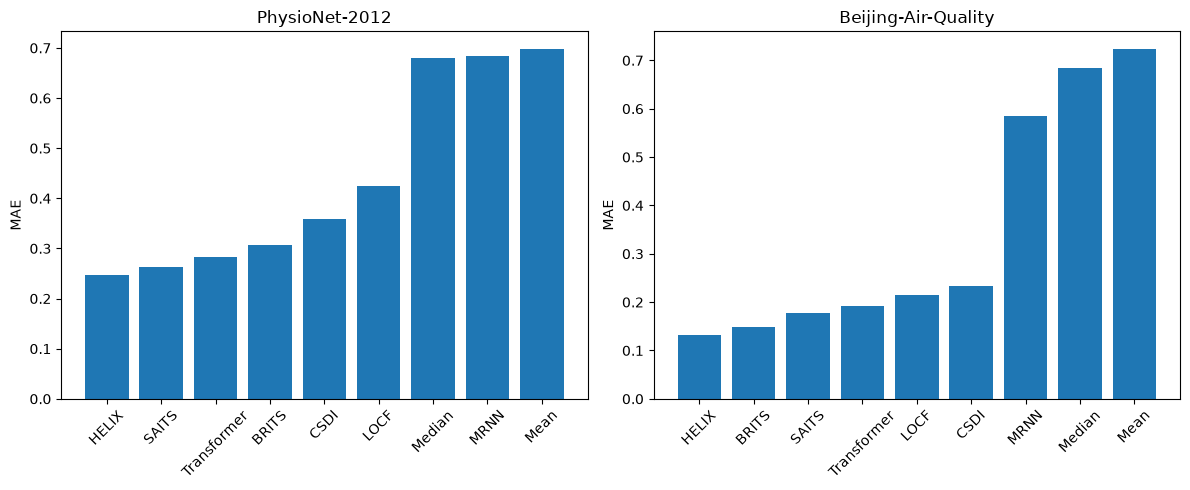

In [11]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(12, 5), sharey=False)
for ax, dataset in zip(axes, DATASETS):
    subset = results_df[results_df["dataset"] == dataset["name"]].sort_values("MAE")
    ax.bar(subset["model"], subset["MAE"])
    ax.set_title(dataset["name"])
    ax.set_ylabel("MAE")
    ax.tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("imputation_benchmark_mae.png", dpi=150)
plt.show()


In [38]:
from great_tables import GT, loc, style

table_screenshot = (
    GT(results_df)
    .tab_header(
        title="Model Performance Overview",
        subtitle="Benchmark scores across datasets"
    )
    .cols_label(
        dataset="Dataset",
        model="Model",
        MAE="MAE ↓",
        MSE="MSE ↓",
        MRE="MRE ↓",
        train_time_sec="Training Time (s)",
        train_parameters="Parameters"
    )
    .fmt_number(
        columns=["MAE", "MSE", "MRE"],
        decimals=4
    )
    .fmt_number(
        columns="train_time_sec",
        decimals=1
    )
    .fmt_number(
        columns="train_parameters",
        decimals=0
    )
    .data_color(
        columns=["MAE", "MSE", "MRE"],
        palette=["#22c55e", "#facc15", "#ef4444"]
    )
    .tab_style(
        style=style.fill("#111827"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=[
            style.text(
                color="white",
                weight="bold"
            )
        ],
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.text(size="12px"),
        locations=loc.body()
    )
)

In [39]:
table_screenshot

GT(_tbl_data=                dataset        model     MAE     MSE     MRE  train_time_sec  \
17  Beijing-Air-Quality        HELIX  0.1314  0.2159  0.1741           432.5   
13  Beijing-Air-Quality        BRITS  0.1494  0.1521  0.1979            64.4   
15  Beijing-Air-Quality        SAITS  0.1772  0.2803  0.2348             9.1   
14  Beijing-Air-Quality  Transformer  0.1929  0.2937  0.2556             6.3   
11  Beijing-Air-Quality         LOCF  0.2144  0.3670  0.2841             0.0   
16  Beijing-Air-Quality         CSDI  0.2342  3.7252  0.3103          2225.4   
12  Beijing-Air-Quality         MRNN  0.5842  0.7630  0.7739            94.6   
10  Beijing-Air-Quality       Median  0.6845  1.1829  0.9068             0.0   
9   Beijing-Air-Quality         Mean  0.7239  1.1218  0.9590             0.0   
8        PhysioNet-2012        HELIX  0.2465  0.2716  0.3528           461.2   
6        PhysioNet-2012        SAITS  0.2631  0.2941  0.3765            27.4   
5        PhysioNet-2012  Transformer  0.2821  0.3216  0.4038            16.5   
4        PhysioNet-2012        BRITS  0.3062  0.3785  0.4383           170.0   
7        PhysioNet-2012         CSDI  0.3594  0.6403  0.5145          2111.0   
2        PhysioNet-2012         LOCF  0.4250  0.6574  0.6083             0.0   
1        PhysioNet-2012       Median  0.6806  1.0031  0.9742             0.0   
3        PhysioNet-2012         MRNN  0.6842  0.8965  0.9793            42.3   
0        PhysioNet-2012         Mean  0.6983  0.9665  0.9995             0.0   

    train_parameters  
17          801339.0  
13          343328.0  
15          668048.0  
14          314884.0  
11               NaN  
16          336609.0  
12           96585.0  
10               NaN  
9                NaN  
8           800579.0  
6           561206.0  
5           278309.0  
4            92528.0  
7           335849.0  
2                NaN  
1                NaN  
3            32175.0  
0                NaN  , _body=<great_tables._gt_data.Body object at 0x7ff0f7a08830>, _boxhead=Boxhead([ColInfo(var='dataset', type=<ColInfoTypeEnum.default: 1>, column_label='Dataset', column_align='left', column_width=None), ColInfo(var='model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='left', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE ↓', column_align='right', column_width=None), ColInfo(var='MSE', type=<ColInfoTypeEnum.default: 1>, column_label='MSE ↓', column_align='right', column_width=None), ColInfo(var='MRE', type=<ColInfoTypeEnum.default: 1>, column_label='MRE ↓', column_align='right', column_width=None), ColInfo(var='train_time_sec', type=<ColInfoTypeEnum.default: 1>, column_label='Training Time (s)', column_align='right', column_width=None), ColInfo(var='train_parameters', type=<ColInfoTypeEnum.default: 1>, column_label='Parameters', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7ff0f6ae99b0>, _spanners=Spanners([]), _heading=Heading(title='Model Performance Overview', subtitle='Benchmark scores across datasets', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7ff0f7a129f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7ff0f7a12d50>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='MAE', rows=[0], mask=None), grpname=None, colname='MAE', rownum=0, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#22c55e')]), StyleInfo(locname=LocBody(columns='MAE', rows=[1], mask=None), grpname=None, colname='MAE', rownum=1, colnum=None, styles=[CellStyleText(color='#000000', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#2fc55a')]), StyleInfo(